<a id="top"></a>
# Estimating Galaxy Cluster Masses with Convolutional Neural Networks

***

## Imports
This notebook uses the following:
- *numpy* to handle array functions
- *astropy.io fits* for accessing FITS files
- *matplotlib.pyplot* for plotting data
- *keras* for building the CNN

In [1]:
#%matplotlib widget
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import keras
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D
from keras.layers import GlobalAveragePooling2D

print('Approach 2 training device: CPU:0')

Approach 2 training device: CPU:0


### 1. Load the data

The FITS file contains the X-ray images and metadata, including `cluster_id`, `view_los`, `log_M500`, and the original train/validation/test flags.

In [2]:
filename = r'/Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/cluster_TNG_data.fits'
hdul = fits.open(filename)
image_size = hdul[1].data.shape[1]

### 2. Prepare the baseline split

The original split is retained for the baseline model. The cross-validation model below uses cluster-level folds instead, preventing different views of one cluster from appearing in both training and validation data.

In [3]:
train_ind = np.argwhere(hdul[2].data['train'] == 1)
train_X = hdul[1].data[train_ind].reshape(-1, image_size, image_size, 1)
train_Y = hdul[2].data['log_M500'][train_ind]

val_ind = np.argwhere(hdul[2].data['validate'] == 1)
val_X = hdul[1].data[val_ind].reshape(-1, image_size, image_size, 1)
val_Y = hdul[2].data['log_M500'][val_ind]

test_ind = np.argwhere(hdul[2].data['test'] == 1)
test_X = hdul[1].data[test_ind].reshape(-1, image_size, image_size, 1)
test_Y = hdul[2].data['log_M500'][test_ind]

ML models often converge faster when the output is _roughly_ between 0 and 1. Next, let's perform a normalization that will speed up the training process a bit -- calculate the minimum log(mass) and subtract it from the Y labels as a change of units.  We'll put it back, later in the notebook, just before we plot the results.  

We can simply subtract off a constant value because our output doesn't have a large dynamical range, but there may be cases where you want to handle this more carefully and force all of your labels to be strictly in the (0,1) interval.  

In [4]:
norm = np.nanmin(hdul[2].data['log_M500'])
train_Y -= norm
val_Y -= norm
test_Y -= norm

### 3. Build a CNN in Keras

Here, we will build the model described in Section 2.2 of [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract)

Further details about Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, and Dense layers can be found in the [Keras Layers Documentation](https://keras.io/api/layers/).  Further details about the relu activation function can be found in the [Keras Activation Function Documentation](https://keras.io/api/layers/activations/).

In [5]:
input_shape = (image_size, image_size, 1)
model = Sequential([
    Input(shape=input_shape),
    Conv2D(16, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    GlobalAveragePooling2D(),
    Dropout(0.1),
    Dense(200, activation='relu'),
    Dropout(0.1),
    Dense(100, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear')
])

2026-08-28 07:14:23.781191: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-08-28 07:14:23.781221: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-08-28 07:14:23.781226: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1787872463.781238 1343424 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1787872463.781257 1343424 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### 4. Compile the CNN

Next, we compile the model.  As in [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract), we select the Adam opmimizer (with a learning rate that is slightly decreased from the default rate) and the mean squared error loss function.

You can learn more about [optimizers](https://keras.io/api/optimizers/) and more about [loss functions for regression tasks](https://keras.io/api/losses/) in the [Keras documentation](https://keras.io/)

In [6]:
model.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(learning_rate=0.0002))

### 5. Train the CNN to perform a regression task

We will start with training for 5 epochs, but this almost certainly won't be long enough to get great results.  Once you've run your model and evaluated the fit, you can come back here and run the next cell again for 100 epochs or longer.  

You can learn more about model.fit [here](https://keras.rstudio.com/reference/fit.html)

In [7]:
epochs = 5
batch_size = 16 #lower this value if you get a memory error
hist = model.fit(train_X, train_Y, batch_size=batch_size, verbose=True,  epochs=epochs)

Epoch 1/5


2026-08-28 07:14:24.665832: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 3.2979
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.6073
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 7.2791
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 3.0841
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 9.6511


# Approch 2

## Add cluster aware cross-validation

The following cells convert the FITS metadata to a DataFrame, check cluster completeness, and run cluster-aware cross-validation.

In [8]:
data = {}

table = hdul[2].data

for name in table.names:
    arr = np.array(table[name])

    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.astype(arr.dtype.newbyteorder('='))

    data[name] = arr

df = pd.DataFrame(data)

### 3. Check cluster completeness

Each complete cluster should contain exactly the three lines of sight: `x`, `y`, and `z`. Incomplete clusters are excluded from cross-validation.

In [9]:
# Verify that every cluster has exactly the three expected lines of sight.
los_by_cluster = df.groupby('cluster_id')['view_los'].agg(lambda values: set(values))
expected_los = set(df['view_los'].dropna().unique())
complete_clusters = los_by_cluster[los_by_cluster == expected_los].index.to_numpy()
incomplete_clusters = los_by_cluster[los_by_cluster != expected_los]

print(f'Expected lines of sight: {sorted(expected_los)}')
print(f'Complete clusters: {len(complete_clusters)} out of {len(los_by_cluster)}')
print('Incomplete or duplicated clusters:')
print(incomplete_clusters)

assert all(len(df[df['cluster_id'] == cid]) == len(expected_los) for cid in complete_clusters), \
    'At least one cluster has duplicate rows for a line of sight.'

Expected lines of sight: ['x', 'y', 'z']
Complete clusters: 328 out of 329
Incomplete or duplicated clusters:
cluster_id
0    {z, y}
Name: view_los, dtype: object


In [10]:
images = hdul[1].data

### 6. Cluster-aware 10-fold cross-validation

The CV loop splits complete `cluster_id` groups, so all three lines of sight remain in the same fold. Cluster 0 is excluded because it is incomplete. Set `epochs` and uncomment `cv_rot` when the rotation-augmented comparison is needed.

In [11]:
n_folds = 10
epochs = 50
batch_size = 16

# `clusters` contains one entry per cluster, not one entry per image.
# Therefore KFold assigns complete cluster IDs to folds.
clusters = np.sort(complete_clusters)
assert len(clusters) >= n_folds

# Store every image row belonging to each cluster. These indices are expanded
# only after the cluster-level fold assignment has been made.
cluster_indices = {
    cid: df.index[df['cluster_id'] == cid].to_numpy()
    for cid in clusters
}
cluster_masses = {
    cid: df.loc[df['cluster_id'] == cid, 'log_M500'].iloc[0]
    for cid in clusters
}
norm_cv = np.nanmin(list(cluster_masses.values()))
cluster_masses = {cid: mass - norm_cv for cid, mass in cluster_masses.items()}

In [12]:
def build_model(with_rotation=False, input_shape=(*images.shape[1:], 1)):
    model_layers = [Input(shape=input_shape)]
    if with_rotation:
        model_layers.extend([
            keras.layers.RandomRotation(0.25),
            keras.layers.RandomFlip('horizontal'),
            keras.layers.RandomFlip('vertical')
        ])
    model_layers.extend([
        Conv2D(16, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        GlobalAveragePooling2D(),
        Dropout(0.1),
        Dense(200, activation='relu'),
        Dropout(0.1),
        Dense(100, activation='relu'),
        Dense(20, activation='relu'),
        Dense(1, activation='linear')
    ])
    model = Sequential(model_layers)
    model.compile(loss='mean_squared_error',
                  optimizer=keras.optimizers.Adam(learning_rate=0.0002),
                  run_eagerly=True,
                  jit_compile=False)
    return model

In [13]:
def run_cv(with_rotation=False):
    folds = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results = []
    fold_histories = []
    fold_predictions = []

    for fold, (train_ids, val_ids) in enumerate(folds.split(clusters), start=1):
        # KFold splits unique cluster IDs, so no cluster can be in both sets.
        train_clusters = clusters[train_ids]
        val_clusters = clusters[val_ids]

        # Expand cluster IDs into image rows only after the split.
        train_indices = np.concatenate([cluster_indices[cid] for cid in train_clusters])
        val_indices = np.concatenate([cluster_indices[cid] for cid in val_clusters])
        train_X = images[train_indices].reshape(-1, *images.shape[1:], 1)
        val_X = images[val_indices].reshape(-1, *images.shape[1:], 1)
        train_Y = np.repeat([cluster_masses[cid] for cid in train_clusters], 3)
        val_Y = np.repeat([cluster_masses[cid] for cid in val_clusters], 3)

        print(
            f'Fold {fold}/{n_folds} starting | '
            f'train: {len(train_clusters)} clusters, {len(train_indices)} images | '
            f'validation: {len(val_clusters)} clusters, {len(val_indices)} images'
        )
        with tf.device('/CPU:0'):
            model = build_model(with_rotation=with_rotation)
            history = model.fit(train_X, train_Y,
                                validation_data=(val_X, val_Y),
                                batch_size=batch_size, epochs=epochs, verbose=1)
            predictions = model.predict(val_X, batch_size=batch_size, verbose=0).flatten()
        residuals = predictions - val_Y
        fold_histories.append(history)
        fold_predictions.append({
            'fold': fold,
            'true': val_Y.copy(),
            'predicted': predictions.copy(),
            'residuals': residuals.copy(),
        })
        fold_results.append({
            'fold': fold,
            'r2': r2_score(val_Y, predictions),
            'mae': mean_absolute_error(val_Y, predictions),
            'rmse': np.sqrt(mean_squared_error(val_Y, predictions)),
            'scatter': np.std(residuals),
            'bias': np.mean(residuals),
            'val_loss': history.history['val_loss'][-1]
        })
        fold_result = fold_results[-1]
        print(
            f"Fold {fold}/{n_folds} complete | R2={fold_result['r2']:.4f}, "
            f"MAE={fold_result['mae']:.4f}, RMSE={fold_result['rmse']:.4f}"
        )
        print('-' * 72)

    return pd.DataFrame(fold_results), fold_histories, fold_predictions

In [14]:
cv_no_rot, histories_no_rot, predictions_no_rot = run_cv(with_rotation=False)
print(cv_no_rot)
print('\n10-fold CV summary:')
print(cv_no_rot[['r2', 'mae', 'rmse', 'scatter', 'bias']].agg(['mean', 'std']))

# Run the augmented comparison when needed:
# cv_rot, histories_rot, predictions_rot = run_cv(with_rotation=True)

Fold 1/10 starting | train: 295 clusters, 885 images | validation: 33 clusters, 99 images
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.6107 - val_loss: 0.0606
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.1178 - val_loss: 0.0368
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0524 - val_loss: 0.0248
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0371 - val_loss: 0.0245
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0643 - val_loss: 0.0237
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0325 - val_loss: 0.0238
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0320 - val_loss: 0.0246
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0309 - val_loss: 0.0223
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0282 - val_loss: 0.0227
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0256 - val_loss: 0.0223
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss:

### 7. Ten-fold training curves and diagnostics

These plots show whether folds have similar learning behavior and whether performance varies strongly across clusters.

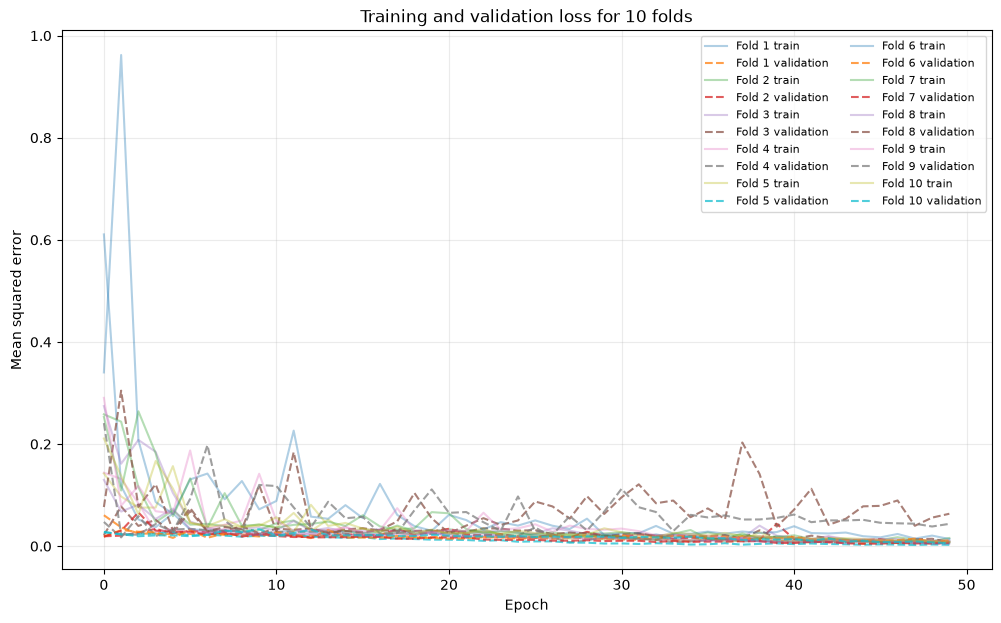

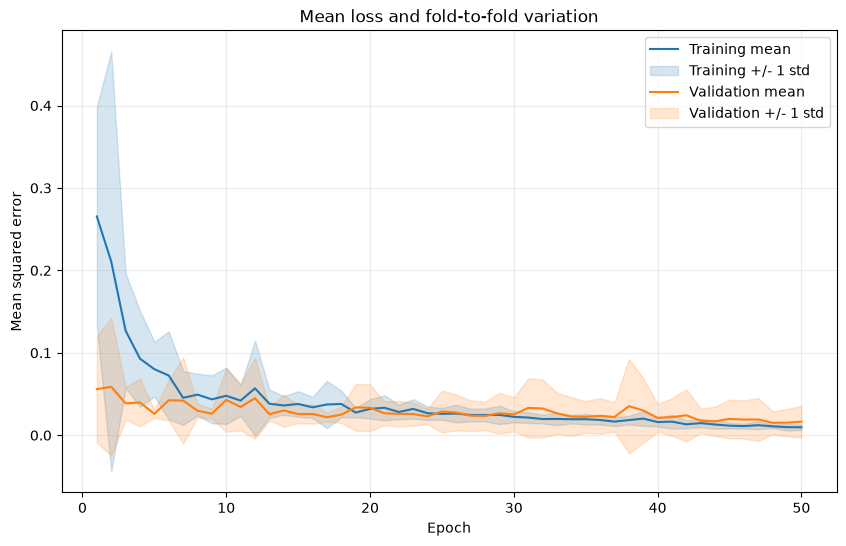

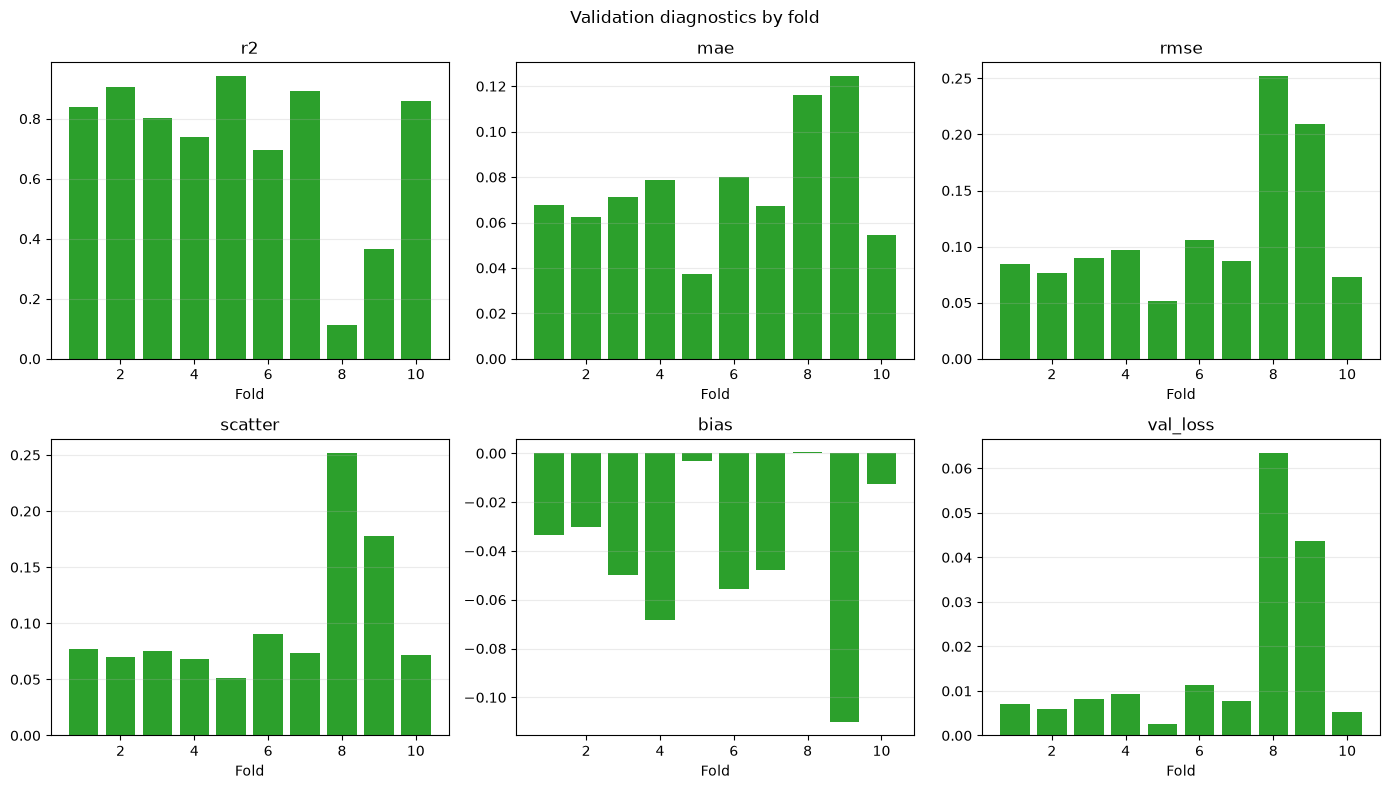

Fold metric summary:


,r2,mae,rmse,scatter,bias,val_loss
mean,0.715403,0.075950,0.112639,0.100762,-0.041011,0.016443
std,0.268558,0.026445,0.064593,0.063308,0.033345,0.020250
min,0.111721,0.037302,0.051564,0.051474,-0.110096,0.002659
max,0.941969,0.124419,0.251949,0.251949,0.000468,0.063478


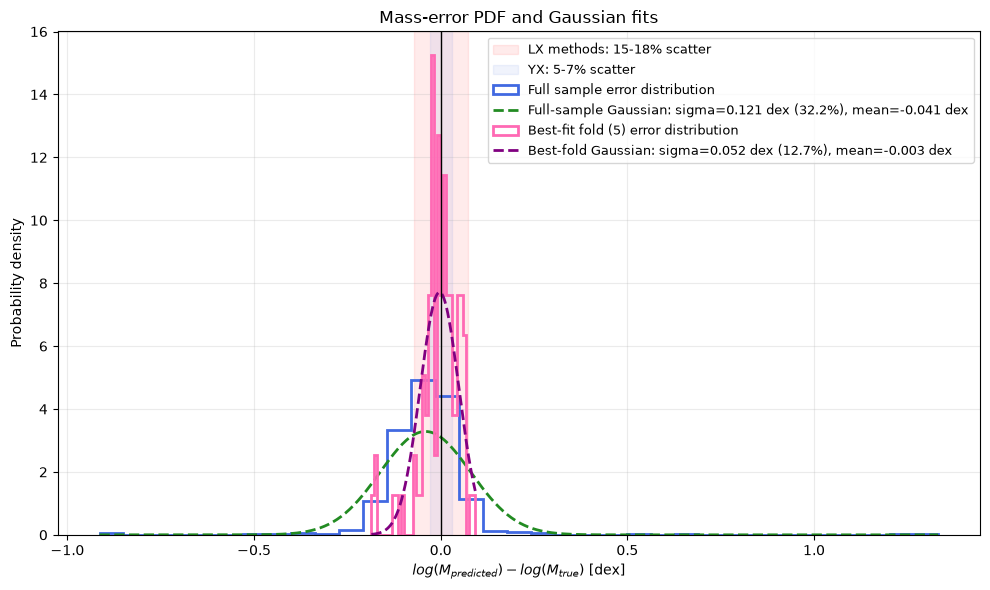

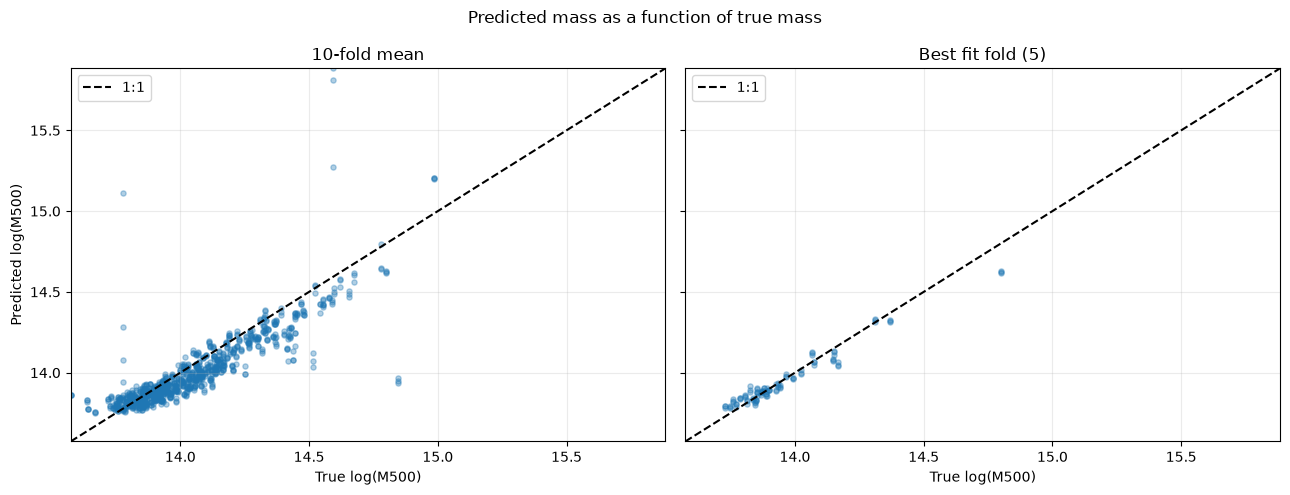

In [21]:
# Plot training and validation loss for every fold.
plt.figure(figsize=(12, 7))
for fold, history in enumerate(histories_no_rot, start=1):
    plt.plot(history.history['loss'], alpha=0.35, label=f'Fold {fold} train')
    plt.plot(history.history['val_loss'], alpha=0.75, linestyle='--', label=f'Fold {fold} validation')
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.title('Training and validation loss for 10 folds')
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=8)
plt.show()

# Plot mean loss and one-standard-deviation spread across folds.
train_loss = np.array([history.history['loss'] for history in histories_no_rot])
val_loss = np.array([history.history['val_loss'] for history in histories_no_rot])
epoch_axis = np.arange(1, train_loss.shape[1] + 1)

plt.figure(figsize=(10, 6))
for losses, label, color in [(train_loss, 'Training', 'C0'), (val_loss, 'Validation', 'C1')]:
    mean_loss = losses.mean(axis=0)
    std_loss = losses.std(axis=0)
    plt.plot(epoch_axis, mean_loss, color=color, label=f'{label} mean')
    plt.fill_between(epoch_axis, mean_loss - std_loss, mean_loss + std_loss,
                     color=color, alpha=0.18, label=f'{label} +/- 1 std')
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.title('Mean loss and fold-to-fold variation')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# Compare final validation metrics across folds.
metrics = ['r2', 'mae', 'rmse', 'scatter', 'bias', 'val_loss']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, metric in zip(axes.flat, metrics):
    axis.bar(cv_no_rot['fold'], cv_no_rot[metric], color='C2')
    axis.set_title(metric)
    axis.set_xlabel('Fold')
    axis.grid(axis='y', alpha=0.25)
plt.suptitle('Validation diagnostics by fold')
plt.tight_layout()
plt.show()

print('Fold metric summary:')
display(cv_no_rot[metrics].agg(['mean', 'std', 'min', 'max']))

# Combine out-of-fold predictions: every validation image appears exactly once.
all_true = np.concatenate([result['true'] for result in predictions_no_rot]) + norm_cv
all_predicted = np.concatenate([result['predicted'] for result in predictions_no_rot]) + norm_cv
all_errors = all_predicted - all_true
best_fold = int(cv_no_rot.loc[cv_no_rot['r2'].idxmax(), 'fold'])
best_result = predictions_no_rot[best_fold - 1]
best_true = best_result['true'] + norm_cv
best_predicted = best_result['predicted'] + norm_cv
best_errors = best_predicted - best_true

# Publication-style mass-error PDFs and Gaussian fits.
def gaussian_pdf(values, points):
    mean = np.mean(values)
    sigma = np.std(values, ddof=1)
    density = np.exp(-0.5 * ((points - mean) / sigma) ** 2)
    return density / (sigma * np.sqrt(2 * np.pi)), mean, sigma

full_points = np.linspace(all_errors.min(), all_errors.max(), 400)
best_points = np.linspace(best_errors.min(), best_errors.max(), 400)
full_gaussian, full_mean, full_sigma = gaussian_pdf(all_errors, full_points)
best_gaussian, best_mean, best_sigma = gaussian_pdf(best_errors, best_points)
full_scatter_percent = 100 * (10 ** full_sigma - 1)
best_scatter_percent = 100 * (10 ** best_sigma - 1)

fig, axis = plt.subplots(figsize=(10, 6))
red_band = np.log10(1 + np.asarray([0.15, 0.18]))
yx_band = np.log10(1 + np.asarray([0.05, 0.07]))
axis.axvspan(-red_band[1], red_band[1], color='red', alpha=0.08,
             label='LX methods: 15-18% scatter')
axis.axvspan(-yx_band[1], yx_band[1], color='royalblue', alpha=0.08,
             label='YX: 5-7% scatter')
axis.hist(all_errors, bins=35, density=True, histtype='step', linewidth=2,
          color='royalblue', label='Full sample error distribution')
axis.plot(full_points, full_gaussian, color='forestgreen', linestyle='--', linewidth=2,
          label=f'Full-sample Gaussian: sigma={full_sigma:.3f} dex ({full_scatter_percent:.1f}%), mean={full_mean:.3f} dex')
axis.hist(best_errors, bins=35, density=True, histtype='step', linewidth=2,
          color='hotpink', label=f'Best-fit fold ({best_fold}) error distribution')
axis.plot(best_points, best_gaussian, color='purple', linestyle='--', linewidth=2,
          label=f'Best-fold Gaussian: sigma={best_sigma:.3f} dex ({best_scatter_percent:.1f}%), mean={best_mean:.3f} dex')
axis.axvline(0, color='black', linewidth=1)
axis.set_xlabel(r'$log(M_{predicted}) - log(M_{true})$ [dex]')
axis.set_ylabel('Probability density')
axis.set_title('Mass-error PDF and Gaussian fits')
axis.grid(alpha=0.25)
axis.legend(fontsize=9)
fig.tight_layout()
plt.show()

# Show predicted mass versus true mass with the one-to-one reference line.
axis_limits = [min(all_true.min(), all_predicted.min()), max(all_true.max(), all_predicted.max())]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for axis, true_values, predicted_values, title in [
    (axes[0], all_true, all_predicted, '10-fold mean'),
    (axes[1], best_true, best_predicted, f'Best fit fold ({best_fold})'),
]:
    axis.scatter(true_values, predicted_values, s=14, alpha=0.35)
    axis.plot(axis_limits, axis_limits, 'k--', linewidth=1.5, label='1:1')
    axis.set(title=title, xlabel='True log(M500)', xlim=axis_limits, ylim=axis_limits)
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel('Predicted log(M500)')
fig.suptitle('Predicted mass as a function of true mass')
fig.tight_layout()
plt.show()

# Approach 2 outputs
All models, metrics, histories, plots, and plotting scripts are saved under `approach2_outputs`.


In [16]:
from pathlib import Path
import json
output_dir = Path('approach2_outputs')
output_dir.mkdir(exist_ok=True)


In [17]:
cv_no_rot.to_csv(output_dir / 'cv_no_rotation.csv', index=False)
np.savez(
    output_dir / 'training_histories.npz',
    train_loss=np.asarray([h.history['loss'] for h in histories_no_rot]),
    val_loss=np.asarray([h.history['val_loss'] for h in histories_no_rot])
)
np.savez(
    output_dir / 'fold_predictions.npz',
    true=np.asarray([result['true'] for result in predictions_no_rot], dtype=object),
    predicted=np.asarray([result['predicted'] for result in predictions_no_rot], dtype=object)
)
model.save(output_dir / 'last_cv_model.keras')
(output_dir / 'run_metadata.json').write_text(json.dumps({
    'approach': 2,
    'n_folds': int(n_folds),
    'fold_seed': 42,
    'normalization_offset': float(norm_cv)
}, indent=2))
print(f'Saved CV table, histories, fold predictions, and last fold model to {output_dir.resolve()}')

Saved CV table, histories, fold predictions, and last fold model to /Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/approach2_outputs


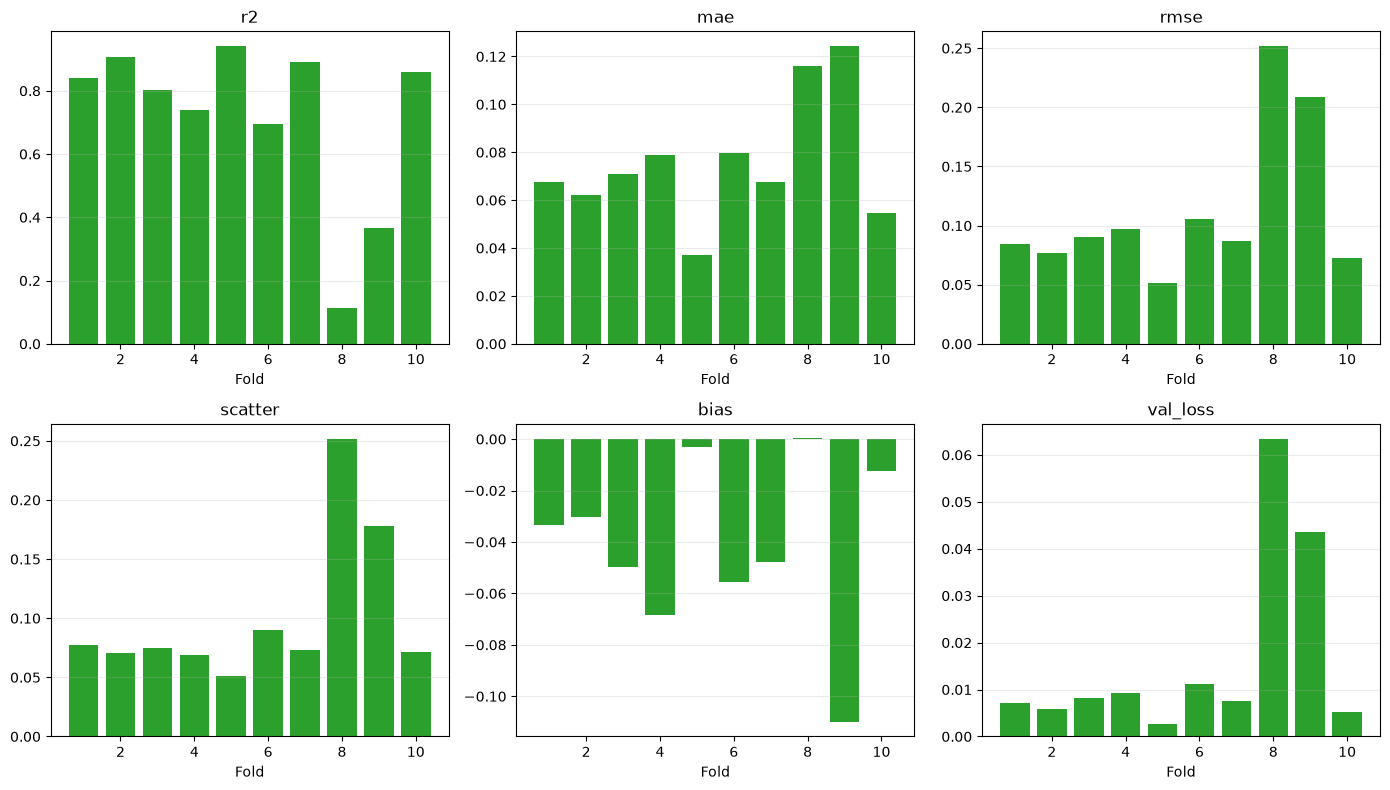

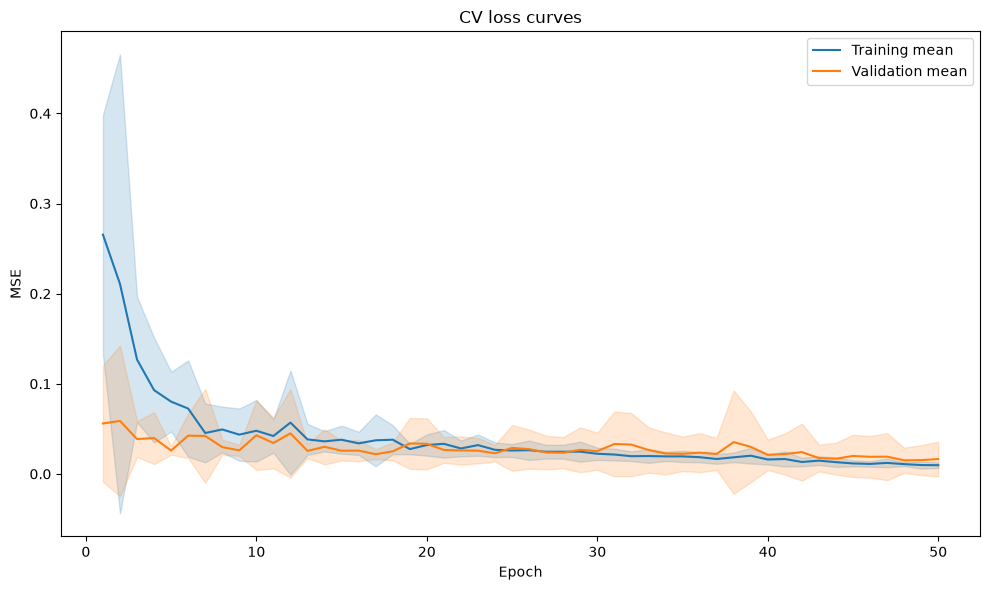

Saved CV plots


In [18]:
metrics = ['r2', 'mae', 'rmse', 'scatter', 'bias', 'val_loss']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, metric in zip(axes.flat, metrics):
    axis.bar(cv_no_rot['fold'], cv_no_rot[metric], color='C2')
    axis.set_title(metric)
    axis.set_xlabel('Fold')
    axis.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(output_dir / 'cv_metrics_by_fold.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
train_loss = np.asarray([h.history['loss'] for h in histories_no_rot])
val_loss = np.asarray([h.history['val_loss'] for h in histories_no_rot])
epoch_axis = np.arange(1, train_loss.shape[1] + 1)
fig, axis = plt.subplots(figsize=(10, 6))
for losses, label, color in [(train_loss, 'Training', 'C0'), (val_loss, 'Validation', 'C1')]:
    mean_loss = losses.mean(axis=0)
    std_loss = losses.std(axis=0)
    axis.plot(epoch_axis, mean_loss, color=color, label=f'{label} mean')
    axis.fill_between(epoch_axis, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.18)
axis.set(xlabel='Epoch', ylabel='MSE', title='CV loss curves')
axis.legend()
fig.tight_layout()
fig.savefig(output_dir / 'cv_loss_curves.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved CV plots')


In [19]:
plot_script = r'''from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path(__file__).resolve().parent
results = pd.read_csv(OUTPUT_DIR / 'cv_no_rotation.csv')
predictions = np.load(OUTPUT_DIR / 'fold_predictions.npz', allow_pickle=True)
metadata = json.loads((OUTPUT_DIR / 'run_metadata.json').read_text())
norm_cv = metadata.get('normalization_offset', 0.0)
true_by_fold = predictions['true']
predicted_by_fold = predictions['predicted']
all_true = np.concatenate(true_by_fold) + norm_cv
all_predicted = np.concatenate(predicted_by_fold) + norm_cv
best_fold = int(results.loc[results['r2'].idxmax(), 'fold'])
best_true = true_by_fold[best_fold - 1] + norm_cv
best_predicted = predicted_by_fold[best_fold - 1] + norm_cv

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, metric in zip(axes.flat, ['r2', 'mae', 'rmse', 'scatter', 'bias', 'val_loss']):
    axis.bar(results['fold'], results[metric], color='C2')
    axis.set(title=metric, xlabel='Fold')
    axis.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'cv_metrics_by_fold.png', dpi=200, bbox_inches='tight')
plt.close(fig)

fig, axis = plt.subplots(figsize=(10, 6))
for values, label, color in [(all_predicted - all_true, '10-fold mean', 'C0'), (best_predicted - best_true, f'Best fit fold ({best_fold})', 'C3')]:
    axis.hist(values, bins=30, density=True, alpha=0.28, color=color, label=f'{label} PDF')
    mean, sigma = np.mean(values), np.std(values, ddof=1)
    points = np.linspace(values.min(), values.max(), 300)
    gaussian = np.exp(-0.5 * ((points - mean) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    axis.plot(points, gaussian, color=color, linewidth=2, label=f'{label}: mean={mean:.3f}, sigma={sigma:.3f}')
axis.axvline(0, color='black', linestyle='--')
axis.set(xlabel='log(Mpredicted) - log(Mtrue)', ylabel='Probability density', title='Mass-error PDFs with Gaussian fits')
axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'mass_error_pdfs_gaussian_fit.png', dpi=200, bbox_inches='tight')
plt.close(fig)

limits = [min(all_true.min(), all_predicted.min()), max(all_true.max(), all_predicted.max())]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for axis, true_values, predicted_values, title in zip(axes, [all_true, best_true], [all_predicted, best_predicted], ['10-fold mean', f'Best fit fold ({best_fold})']):
    axis.scatter(true_values, predicted_values, s=14, alpha=0.35)
    axis.plot(limits, limits, 'k--', linewidth=1.5, label='1:1')
    axis.set(title=title, xlabel='True log(M500)', xlim=limits, ylim=limits)
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel('Predicted log(M500)')
fig.suptitle('Predicted mass as a function of true mass')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'predicted_vs_true_mass.png', dpi=200, bbox_inches='tight')
plt.close(fig)
print(f'Plots regenerated in {OUTPUT_DIR}')
'''
(output_dir / 'plot_outputs.py').write_text(plot_script)
print(f'Saved plotting script to {(output_dir / "plot_outputs.py").resolve()}')

Saved plotting script to /Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/approach2_outputs/plot_outputs.py
